In [1]:
import matplotlib.pyplot as plt
import numpy as np
from lmfit import Minimizer, Parameters
import sys
import pylab as py
import pandas as pd
import csv
import matplotlib.dates as mdates
from scipy import optimize, stats
from importlib import reload
import DataAnalysis.basic_functions as bf
import DataAnalysis.mod_expo_fit_functions as modf
import DataAnalysis.bi_fit_functions as bi_fit
import DataAnalysis.pulser_fit_functions as pf
import DataAnalysis.plot_functions as plotf

sys.path.append('/Users/arleeshelby/ManitobaWork_1374/pyNab/src')
import nabPy as Nab

In [2]:
with open('/Users/arleeshelby/Downloads/Runparameters10_10_12_03.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [3]:
run_numbers = list(np.arange(8622,8633)) + list(np.arange(8635,8638)) + list(np.arange(8643,8660)) + list(np.arange(8681,8695)) + list(np.arange(8696,8700)) + list(np.arange(8704,8714)) + list(np.arange(8715,8722)) + list(np.arange(8824,8833))+list(np.arange(8834,8836)) + list(np.arange(8837,8851)) + list(np.arange(8853,8866))

In [4]:
UDETdata, UDETtime = bf.get_energy_time_data(run_numbers,'UDET')
LDETdata, LDETtime = bf.get_energy_time_data(run_numbers,'LDET')

In [5]:
UDETenergy = bf.get_energy(run_numbers,UDETdata)
LDETenergy = bf.get_energy(run_numbers,LDETdata)

In [6]:
UDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='UDET')
LDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='LDET')

In [7]:
UDETenergy_pulser = bf.get_energy(run_numbers,UDETdata_pulser)
LDETenergy_pulser = bf.get_energy(run_numbers,LDETdata_pulser)

In [10]:
bin_edges = UDETdata[8715]['bin_edges']['0']['37']
bin_edges_pulser = UDETdata_pulser[8622]['bin_edges']['0']['60']
bin_edges_pulser112 = UDETdata_pulser[8622]['bin_edges']['0']['pulser BC 112']

In [374]:
LDETpixels = ['1009','1010','1011','1012','1013','1017','1018','1019','1020','1021','1022','1023','1026','1027','1028','1029','1030','1031','1032',
               '1033','1037','1038','1039','1040','1041','1042','1043','1044','1047','1048','1049','1050','1051','1052','1053','1054','1055','1056',
               '1060','1061','1062','1062','1063','1064','1065','1066','1067','1068','1069','1072','1073','1074','1075','1076','1077','1078','1079','1080',
               '1081','1084','1085','1086','1087','1088','1089','1090','1091','1092','1094','1095','1096','1098','1099','1100','1101','1102','1105',
               '1107','1108','1109','1111','1116','1117']

In [375]:
UDETpixels = ['9','11','12','17','19','20','21','26','27','28','29','30','31','32','37','38','39','40','41','42','43','47','48','49','50','51','52',
          '53','54','55','60','61','62','63','64','65','66','67','72','73','74','75','76','77','78','79','84','85','86','87','88','89','90','91',
          '94','95','96','97','98','99','100','101','102','105','106','107','108','109','110','115','117']

In [414]:
UDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, UDETpixels, run_numbers, plot=False,detector_type='UDET')

failed Bi fit for run: 8647, pixel: 17, region 1
failed Bi fit for run: 8828, pixel: 17, region 1
failed Bi fit for run: 8847, pixel: 17, region 1
failed Bi fit for run: 8859, pixel: 19, region 1
run: 8630, pixel: 27 too low amp, region 1
failed Bi fit for run: 8689, pixel: 27, region 1
failed Bi fit for run: 8840, pixel: 27, region 1
run: 8624, pixel: 29 too low amp, region 2
failed Bi fit for run: 8834, pixel: 29, region 1
failed Bi fit for run: 8690, pixel: 30, region 1
failed Bi fit for run: 8690, pixel: 30, region 2
failed Bi fit for run: 8715, pixel: 37, region 1
failed Bi fit for run: 8624, pixel: 43, region 1
run: 8624, pixel: 43 too low amp, region 2
run: 8630, pixel: 43 too low amp, region 1
run: 8630, pixel: 43 too low amp, region 2
failed Bi fit for run: 8630, pixel: 43, region 3
run: 8637, pixel: 43 too low amp, region 1
failed Bi fit for run: 8637, pixel: 43, region 2
run: 8683, pixel: 43 too low amp, region 1
run: 8683, pixel: 43 too low amp, region 2
run: 8694, pixel: 4

In [1001]:
LDET_df_test_props = bf.get_results_df(bi_fit.get_UDETbi_fit_results, LDETenergy, bin_edges, LDETpixels, run_numbers, plot=False,detector_type='LDET')


run: 8720, pixel: 1011 too low amp, sig1 or sig2 region 1
failed Bi fit for run: 8720, pixel: 1011, region 3
failed Bi fit for run: 8826, pixel: 1011, region 3
failed Bi fit for run: 8857, pixel: 1011, region 3
LDET average too low, run 8644, pixel 1012
failed Bi fit for run: 8644, pixel: 1012, region 2
LDET average too low, run 8697, pixel 1012
run: 8697, pixel: 1012 too low amp, region 2
failed Bi fit for run: 8719, pixel: 1012, region 1
failed Bi fit for run: 8829, pixel: 1012, region 1
LDET average too low, run 8863, pixel 1012
failed Bi fit for run: 8863, pixel: 1012, region 2
LDET average too low, run 8626, pixel 1013
failed Bi fit for run: 8626, pixel: 1013, region 2
failed Bi fit for run: 8626, pixel: 1013, region 3
LDET average too low, run 8644, pixel 1013
LDET average too low, run 8651, pixel 1013
LDET average too low, run 8685, pixel 1013
failed Bi fit for run: 8685, pixel: 1013, region 2
LDET average too low, run 8697, pixel 1013
LDET average too low, run 8705, pixel 1013


In [1215]:
# test_runs = [8622,8623,8624,8637,8649,8654,8684,8685,8689,8690,8706,8716,8830,8835,8837,8845,8850,8860]
# test_pixels = ['20','27','30','32','43','64','66','72','87','89','95','109','110']
# test_runs = [8624,8628,8643,8644,8693,8696,8712,8718,8719,8720,8829,8837,8838]
# test_pixels = ['1012','1020','1026','1030','1033','1042','1043','1044','1065','1069']
test_runs = [8708,8651]
test_pixels = ['109','32']

In [1228]:
# plt.step(bin_edges[0:3000],LDETenergy[8644]['1043'][0:3000])

In [942]:
reload(bi_fit)

<module 'DataAnalysis.bi_fit_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/bi_fit_functions.py'>

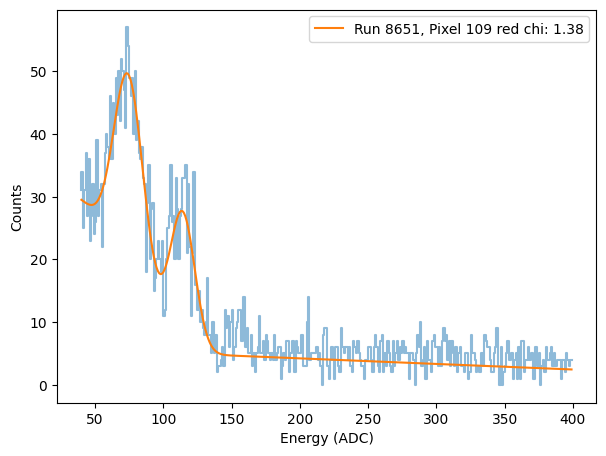

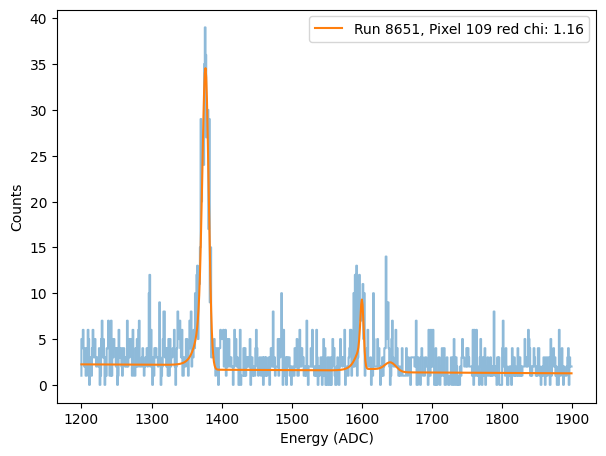

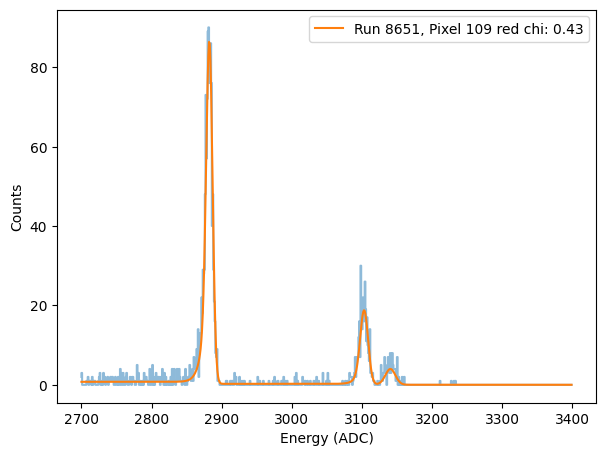

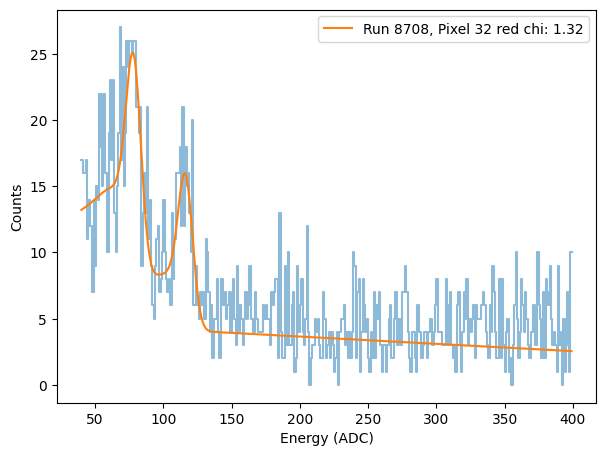

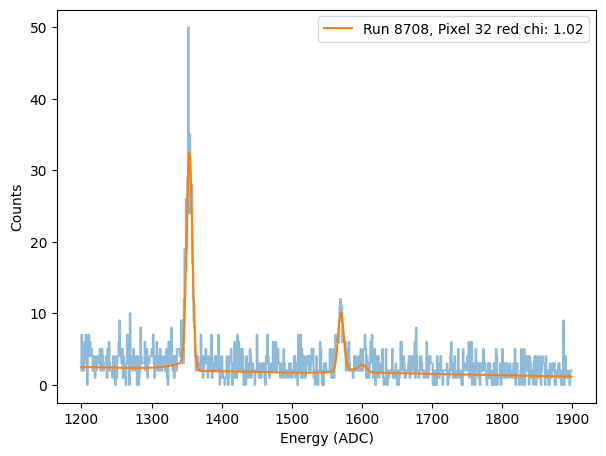

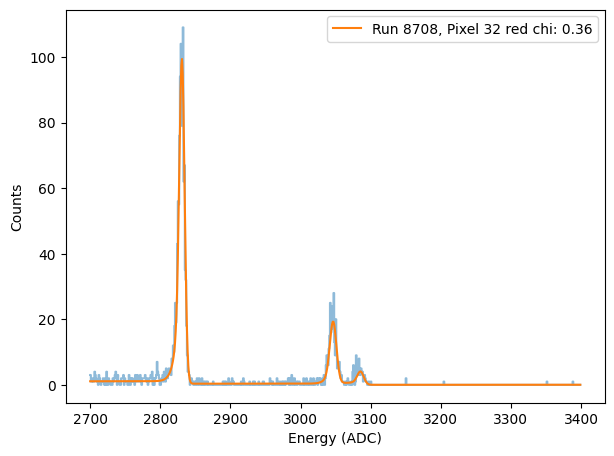

In [1219]:
LDET_test_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, test_pixels, test_runs, plot=True,detector_type='UDET')

In [1054]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

LDETsimulated_keV_values = np.array([22.269661+30,35.276915+30,450.020179+30,522.714534+30,535.039+30,
                                     944.193705+30,1016.613371+30,1029.008589+30])
LDETsimulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [761]:
calibration_peak_data,calibration_width_data,calibration_amp_data = bf.get_cal_peaks_df(UDET_df,simulated_keV_values,simulated_keV_errors)

In [1229]:
LDETcalibration_peak_data,LDETcalibration_width_data,LDETcalibration_amp_data = bf.get_cal_peaks_df(LDET_df_test_props,LDETsimulated_keV_values,LDETsimulated_keV_errors)



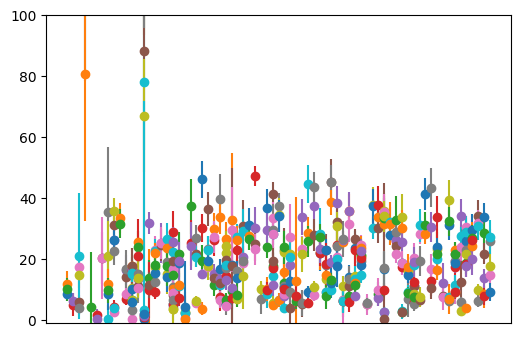

In [1230]:
plotf.plot_peak_fit_params(LDETcalibration_amp_data,peak='peak5',bottom_ylim=-1,top_ylim=100)

In [1231]:
pixels = list(LDETcalibration_amp_data.keys())
for pixel in pixels:
    runs = list(LDETcalibration_amp_data[pixel].keys())
    for run in runs:
        try:
            amp = LDETcalibration_amp_data[pixel][run]['peak4']['value']
            error = LDETcalibration_amp_data[pixel][run]['peak4']['error']
            if amp<1:
                print(pixel,run,amp,error)
        except Exception as e:
            continue

1021 8829 1.7848680837762032e-06 1.7388259794761258


In [1225]:
pixels = list(calibration_amp_data.keys())
for pixel in pixels:
    runs = list(calibration_amp_data[pixel].keys())
    for run in runs:
        try:
            amp = calibration_amp_data[pixel][run]['peak3']['value']
            error = calibration_amp_data[pixel][run]['peak3']['error']
            if amp<50:
                print(pixel,run,amp,error)
        except Exception as e:
            continue

27 8630 25.195325433268458 2.8870601180860294
27 8689 20.16406327607819 2.7553900750119285
27 8840 26.215250694761107 2.679914404456502
32 8654 28.559497359614703 2.436890575712369
32 8708 30.35968449747513 2.315247909990773
32 8854 35.382960261152455 6.9852537267654045
52 8709 38.55823589020378 2.6544165315322084
52 8855 42.78171445645725 4.121369505707245
64 8681 43.290597271643044 3.3983406924306316
87 8626 24.24988269925393 2.3384229014728377
87 8685 38.42401784275149 3.243877862592101
89 8682 23.912293490278397 1.9981224339708248
100 8652 33.7856681873026 3.141050947045069
100 8850 29.872990896889075 2.715439049203202
109 8651 31.037563377939776 2.6656658215987483
109 8652 19.65501556910509 1.8493353943048159
109 8705 29.56544381544192 3.0354392062414175
110 8649 40.45632487668338 4.472910092887661
110 8716 27.771351887385837 2.071449073886249
110 8845 35.169549800481576 2.7331821666046148


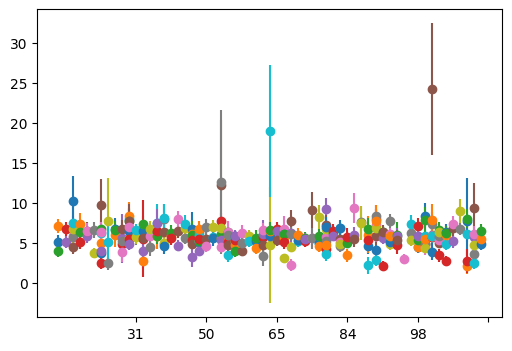

In [725]:
plotf.plot_peak_fit_params(calibration_width_data,peak='peak5',bottom_ylim=None,top_ylim=None)

In [727]:
calibration_linear_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='linear')
calibration_quadratic_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='quadratic')

In [1227]:
reload(bf)

<module 'DataAnalysis.basic_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/basic_functions.py'>

In [1176]:
LDETcalibration_linear_results = bf.calibrate_data(LDETcalibration_peak_data,LDETcalibration_amp_data,calibration_order='linear',detector='LDET')
LDETcalibration_quadratic_results = bf.calibrate_data(LDETcalibration_peak_data,LDETcalibration_amp_data,calibration_order='quadratic',detector='LDET')

In [1177]:
LDETcalibration_linear_results_test = bf.calibrate_data(LDETcalibration_peak_data_test,LDETcalibration_amp_data_test,calibration_order='linear',detector='LDET')
LDETcalibration_quadratic_results_test = bf.calibrate_data(LDETcalibration_peak_data_test,LDETcalibration_amp_data_test,calibration_order='quadratic',detector='LDET')

In [728]:
keys = list(calibration_linear_results.keys())
runs_calibrated = []
for i in keys:
    runs = list(calibration_linear_results[i].keys())
    for j in range(len(runs)):
        if any(value==str(runs[j]) for value in runs_calibrated):
            pass
        else:
            runs_calibrated.append(str(runs[j]))

In [729]:
runs_calibrated
with open('DatabaseFiles/Runs/calibrated_runs.txt', 'w') as file:
    file.write('\n'.join(runs_calibrated))

In [731]:
with open('DatabaseFiles/Runs/run_db.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [732]:
metadata

,run_number,UDET_bias,LDET_bias,HV,MAIN,UDET,date,start_time,end_time,ExB,UDET_armor,UDET_ring,LDET_armor,UDET_leakage,LDET_leakage
0,8655,300.0,300.0,27.0,137.0,137.0,2025-10-14,20:51:38,20:51:36,-1499.050847,134.458618,119.984912,129.964194,0.007057,35.94986
1,8709,300.0,300.0,27.0,137.0,137.0,2025-10-21,19:48:30,19:48:28,-1499.000000,134.458499,119.991606,129.974482,0.007585,35.96716
2,8855,300.0,300.0,27.0,137.0,137.0,2025-10-31,15:31:48,15:31:46,-1499.117949,134.275259,120.013290,130.077537,0.007338,35.86735
3,8646,300.0,300.0,27.0,137.0,137.0,2025-10-14,15:35:23,15:35:21,-1499.078125,134.468330,119.999757,129.926447,0.007080,35.94495
4,8848,300.0,300.0,27.0,137.0,137.0,2025-10-30,20:20:45,20:20:43,-1499.000000,134.306473,120.004832,130.048831,0.007573,35.63690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,8720,300.0,300.0,27.0,137.0,137.0,2025-10-22,16:18:29,16:50:08,-1499.028090,134.445196,120.003004,130.028883,0.007329,36.64413
100,8826,300.0,300.0,27.0,137.0,137.0,2025-10-29,19:53:08,20:23:09,-1499.386364,134.329690,119.994170,130.084202,0.008578,36.42743
101,8857,300.0,300.0,27.0,137.0,137.0,2025-10-31,16:42:53,17:17:46,-1499.062802,134.281502,120.014718,130.094448,0.007322,36.35307
102,8719,300.0,300.0,27.0,137.0,137.0,2025-10-22,15:45:26,16:15:26,-1499.269962,134.445041,120.003693,130.040813,0.007344,36.53752


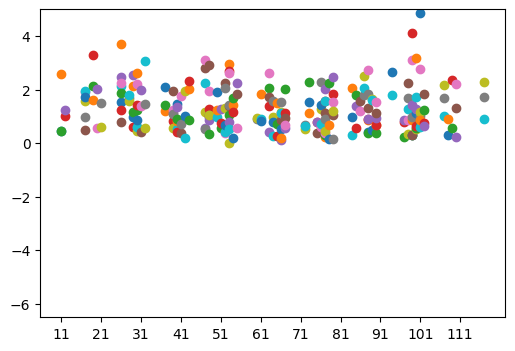

In [736]:
plotf.plot_goodness_of_fit(calibration_linear_results,chi2=False,reduced_chi2=True,bottom_ylim=None,top_ylim=5)

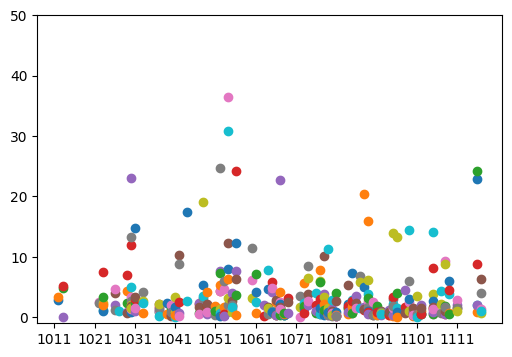

In [766]:
plotf.plot_goodness_of_fit(LDETcalibration_linear_results,chi2=False,reduced_chi2=True,bottom_ylim=-1,top_ylim=50)

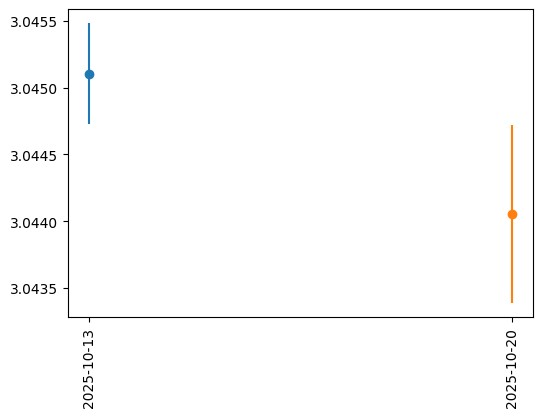

In [1214]:
plotf.plot_calibration_results('109',calibration_linear_results,metadata,gain=True)

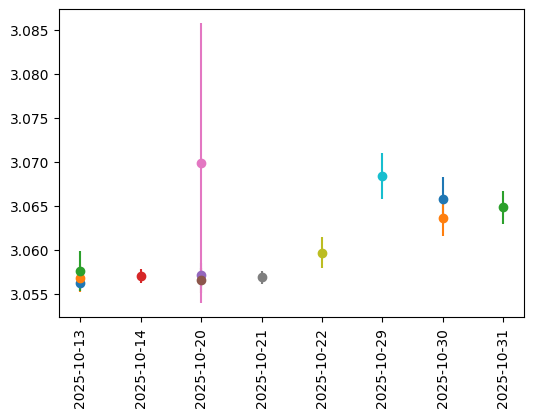

In [1197]:
plotf.plot_calibration_results('1030',LDETcalibration_linear_results_test,metadata,gain=True)

In [1199]:
LDETgain_test['1030']

{8626: {'value': 3.0562583294610244, 'error': 0.0009490146423870084},
 8627: {'value': 3.0568342185872264, 'error': 0.0015496066621473162},
 8636: {'value': 3.057610061472374, 'error': 0.0022978018211414594},
 8659: {'value': 3.057050189927519, 'error': 0.0008234353449021626},
 8685: {'value': 3.0571661592174686, 'error': 0.0013508652792878046},
 8686: {'value': 3.0565474440006786, 'error': 0.0014593400591416405},
 8693: {'value': 3.0698575288493104, 'error': 0.015905858129473874},
 8712: {'value': 3.05689655615863, 'error': 0.0007421222553415246},
 8718: {'value': 3.0597167297795425, 'error': 0.0017760073945682932},
 8830: {'value': 3.0684153824126725, 'error': 0.002608477350888229},
 8837: {'value': 3.0657997553931784, 'error': 0.002451706068689377},
 8838: {'value': 3.06360786912786, 'error': 0.002025582425855405},
 8861: {'value': 3.064839860054395, 'error': 0.0018524091843587036}}

In [1221]:
gain['32']

{8637: {'value': 2.9891674526205283, 'error': 0.0004159161347253773},
 8694: {'value': 2.9887192501416178, 'error': 0.0002290882554689466},
 8860: {'value': 2.9884861951231576, 'error': 0.0007162140314674762}}

In [1224]:
calibration_amp_data['32']

{8637: {'peak1': {'value': 152.18874553460026, 'error': 121.24216385908444},
  'peak2': {'value': 95.96491469524942, 'error': 99.71578150262972},
  'peak3': {'value': 246.40483818207315, 'error': 9.598579009437616},
  'peak4': {'value': 57.89164998218868, 'error': 4.136479483202354},
  'peak5': {'value': 14.26554474677694, 'error': 1.828273660246858},
  'peak6': {'value': 729.243323284213, 'error': 11.956224579305173},
  'peak7': {'value': 148.98337681439955, 'error': 4.09721402253248},
  'peak8': {'value': 42.40065366800935, 'error': 1.8212932616413555}},
 8654: {'peak1': {'value': 17.73276276346206, 'error': 15.056040273226875},
  'peak2': {'value': 9.720002277079058, 'error': 7.190521626049483},
  'peak3': {'value': 28.559497359614703, 'error': 2.436890575712369},
  'peak4': {'value': 9.087055560041302, 'error': 1.6865055187175488},
  'peak5': {'value': 4.954019895830451, 'error': 1.5222769882295846},
  'peak6': {'value': 91.56514704323193, 'error': 2.5002841245619867},
  'peak7': {

In [865]:
pixels = list(LDETgain.keys())
for pixel in pixels:
    runs = list(LDETgain[pixel].keys())
    print(pixel,runs)

1012 [8719, 8829]
1013 [8651, 8705, 8849]
1020 [8720]
1022 [8622, 8681]
1023 [8628, 8687, 8720, 8826, 8842, 8857]
1026 [8627, 8659, 8686, 8712, 8838]
1027 [8718, 8830]
1029 [8697, 8717, 8825, 8863, 8864]
1030 [8626, 8627, 8636, 8659, 8685, 8686, 8693, 8712, 8718, 8830, 8837, 8838, 8861]
1031 [8636, 8652, 8693, 8706, 8718, 8830, 8850, 8861]
1033 [8627, 8659, 8686, 8712, 8838]
1037 [8632, 8650, 8685, 8691, 8704, 8837, 8843, 8844]
1039 [8644, 8863]
1040 [8626, 8651, 8685, 8705, 8837, 8849]
1041 [8632, 8636, 8637, 8650, 8653, 8691, 8693, 8694, 8704, 8843, 8844, 8853, 8860, 8861]
1042 [8624, 8653, 8683, 8707, 8834, 8853]
1043 [8644]
1044 [8626, 8685, 8837]
1047 [8635, 8651, 8692, 8705, 8862]
1048 [8622, 8651, 8681, 8705]
1049 [8628, 8650, 8687, 8704, 8842, 8844]
1051 [8635, 8651, 8692, 8705, 8849, 8862]
1052 [8622, 8628, 8637, 8650, 8681, 8687, 8694, 8704, 8842, 8860]
1053 [8624, 8628, 8637, 8654, 8683, 8687, 8694, 8708, 8834, 8842, 8854, 8860]
1054 [8624, 8630, 8647, 8683, 8692, 8834, 8840

In [1080]:
reload(bf)

<module 'DataAnalysis.basic_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/basic_functions.py'>

In [1081]:
gain = bf.get_calibration_fit_params(calibration_linear_results,gain=True)
offset = bf.get_calibration_fit_params(calibration_linear_results,offset=True)

In [1178]:
LDETgain = bf.get_calibration_fit_params(LDETcalibration_linear_results,gain=True)
LDEToffset = bf.get_calibration_fit_params(LDETcalibration_linear_results,offset=True)

In [1179]:
LDETgain_test = bf.get_calibration_fit_params(LDETcalibration_linear_results_test,gain=True)
LDEToffset_test = bf.get_calibration_fit_params(LDETcalibration_linear_results_test,offset=True)

In [1084]:
average_gain, average_gain_error, gain_std = bf.get_calibration_param_props(gain)
average_gain_weighted, average_gain_error_weighted, gain_std_weighted = bf.get_calibration_param_props(gain,weighted=True)

average_offset, average_offset_error, offset_std = bf.get_calibration_param_props(offset)
average_offset_weighted, average_offset_error_weighted, offset_std_weighted = bf.get_calibration_param_props(offset,weighted=True)

In [1180]:
LDETaverage_gain, LDETaverage_gain_error, LDETgain_std = bf.get_calibration_param_props(LDETgain)
LDETaverage_gain_weighted, LDETaverage_gain_error_weighted, LDETgain_std_weighted = bf.get_calibration_param_props(LDETgain,weighted=True)
LDETaverage_offset, LDETaverage_offset_error, LDEToffset_std = bf.get_calibration_param_props(LDEToffset)
LDETaverage_offset_weighted, LDETaverage_offset_error_weighted, LDEToffset_std_weighted = bf.get_calibration_param_props(LDEToffset,weighted=True)

In [1181]:
LDETaverage_gain_test, LDETaverage_gain_error_test, LDETgain_std_test = bf.get_calibration_param_props(LDETgain_test)
LDETaverage_gain_weighted_test, LDETaverage_gain_error_weighted_test, LDETgain_std_weighted_test = bf.get_calibration_param_props(LDETgain_test,weighted=True)
LDETaverage_offset_test, LDETaverage_offset_error_test, LDEToffset_std_test = bf.get_calibration_param_props(LDEToffset_test)
LDETaverage_offset_weighted_test, LDETaverage_offset_error_weighted_test, LDEToffset_std_weighted_test = bf.get_calibration_param_props(LDEToffset_test,weighted=True)

In [817]:
reload(plotf)

<module 'DataAnalysis.plot_functions' from '/Users/arleeshelby/NabCalibration/DataAnalysis/plot_functions.py'>

In [805]:
np.array(list(map(int, list(LDETaverage_gain_weighted.keys()))))-1000

array([ 12,  13,  20,  22,  23,  26,  27,  29,  30,  31,  33,  37,  39,
        40,  41,  42,  43,  44,  47,  48,  49,  51,  52,  53,  54,  55,
        56,  60,  61,  63,  64,  65,  66,  67,  68,  69,  72,  73,  74,
        76,  77,  78,  79,  80,  81,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  94,  95,  96,  98,  99, 100, 101, 102, 105, 107, 108,
       109, 111, 116, 117])

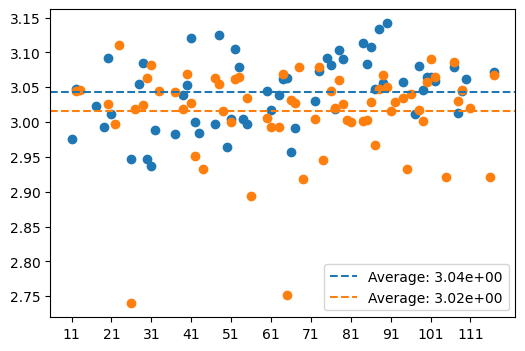

In [1182]:
plotf.plot_calibration_param_props(average_gain_weighted,LDETparam_prop_df=LDETaverage_gain_weighted)

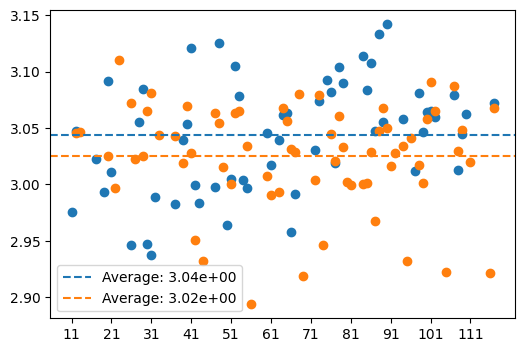

In [1183]:
plotf.plot_calibration_param_props(average_gain_weighted,LDETparam_prop_df=LDETaverage_gain_weighted_test)

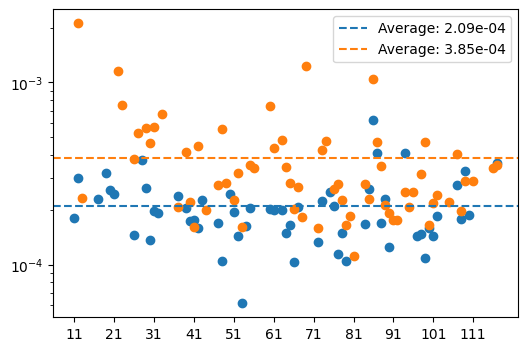

In [1184]:
plotf.plot_calibration_param_props(gain_std_weighted,yscale='log',LDETparam_prop_df=LDETgain_std_weighted)

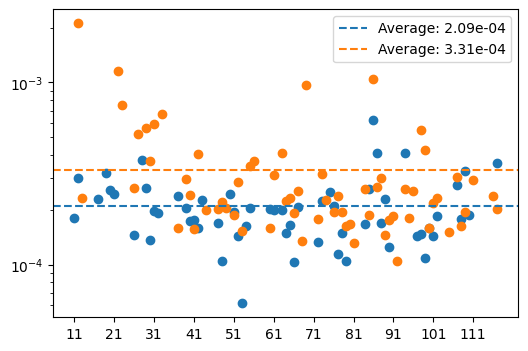

In [1185]:
plotf.plot_calibration_param_props(gain_std_weighted,yscale='log',LDETparam_prop_df=LDETgain_std_weighted_test)

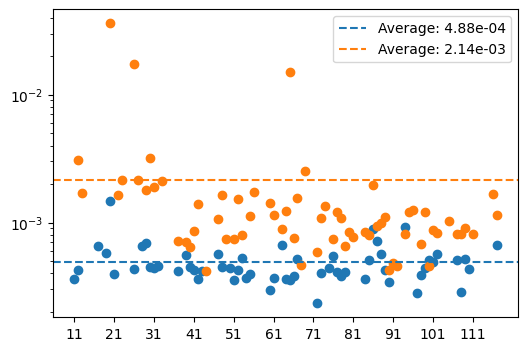

In [1186]:
plotf.plot_calibration_param_props(average_gain_error,yscale='log',LDETparam_prop_df=LDETaverage_gain_error)

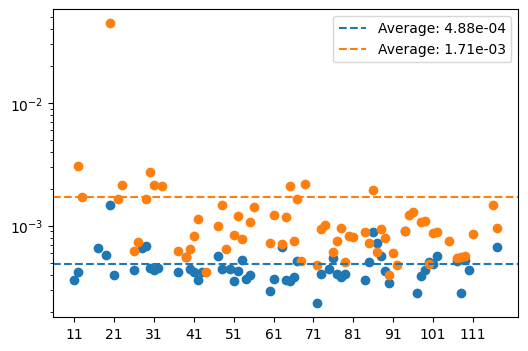

In [1187]:
plotf.plot_calibration_param_props(average_gain_error,yscale='log',LDETparam_prop_df=LDETaverage_gain_error_test)

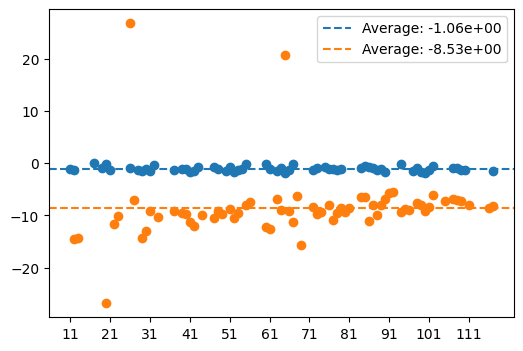

In [1188]:
plotf.plot_calibration_param_props(average_offset,LDETparam_prop_df=LDETaverage_offset)

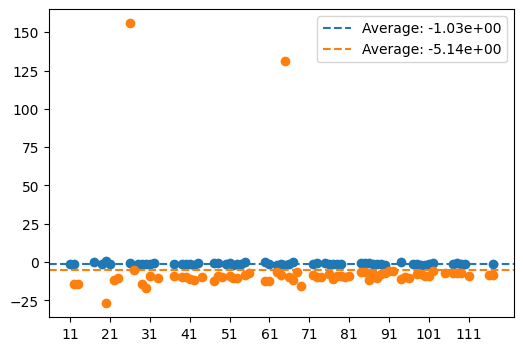

In [1189]:
plotf.plot_calibration_param_props(average_offset_weighted,LDETparam_prop_df=LDETaverage_offset_weighted)

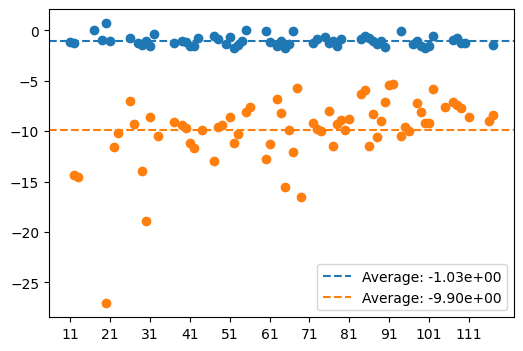

In [1190]:
plotf.plot_calibration_param_props(average_offset_weighted,LDETparam_prop_df=LDETaverage_offset_weighted_test)

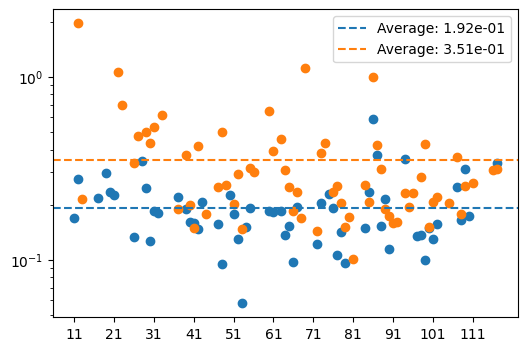

In [1191]:
plotf.plot_calibration_param_props(offset_std_weighted,yscale='log',LDETparam_prop_df=LDEToffset_std_weighted)

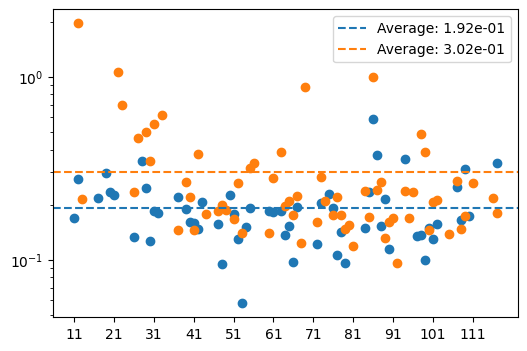

In [1192]:
plotf.plot_calibration_param_props(offset_std_weighted,yscale='log',LDETparam_prop_df=LDEToffset_std_weighted_test)

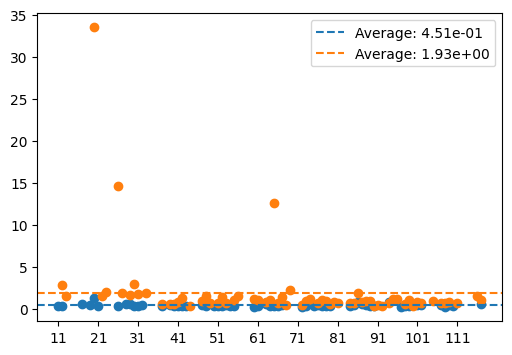

In [1193]:
plotf.plot_calibration_param_props(average_offset_error,LDETparam_prop_df=LDETaverage_offset_error)

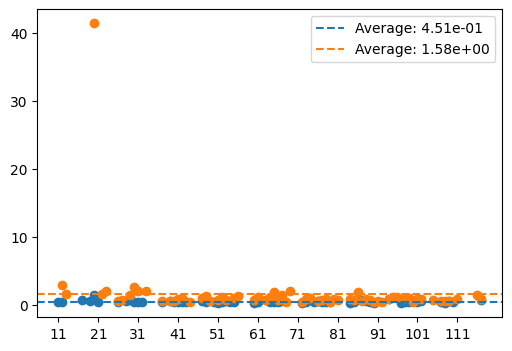

In [1194]:
plotf.plot_calibration_param_props(average_offset_error,LDETparam_prop_df=LDETaverage_offset_error_test)

In [997]:
for key,value in LDETaverage_offset_error.items():
    if value>3:
        print(key,value)

1020 32.53657280145552
1026 14.207990212325
1030 3.0539427042716722
1043 4.708529220072509
1054 3.6792449774993354
1065 12.312146848113638
